# Week 5, Exercise 5.6: VAE Latent Curve Length Evaluation

This notebook evaluates the curve length in both latent and output space
to understand how the VAE decoder transforms curves.

**Reference:** Eq. 4.2 in the LMLG book

## Imports

In [65]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from typing import Callable

## Utility Functions

In [66]:
def compute_curve_length(curve_points: np.ndarray) -> float:
    """
    Compute curve length using Eq. 4.2.
    
    Args:
        curve_points: Array of shape (n_points, d) representing curve points
        
    Returns:
        Curve length (sum of distances between consecutive points)
    """
    differences = curve_points[1:] - curve_points[:-1]
    distances = np.linalg.norm(differences, axis=1)
    return np.sum(distances)

## Load Trained VAE Model

TODO: Load your trained VAE model from Week 1

In [67]:
import sys
import os
sys.path.insert(0, '../Week1')

from vae import GaussianPrior, GaussianEncoder, BernoulliDecoder, VAE

# Load checkpoint 
ckpt_path = './ckpts/model_2d.pt'
state_dict = torch.load(ckpt_path, weights_only=False)

# Infer architecture from state_dict
latent_dim = 2
input_dim = 784
hidden_dim = 512

# Construct encoder network with exact structure from Week1/vae.py
encoder_net = torch.nn.Sequential(
    torch.nn.Flatten(),
    torch.nn.Linear(input_dim, hidden_dim),
    torch.nn.ReLU(),
    torch.nn.Linear(hidden_dim, hidden_dim),
    torch.nn.ReLU(),
    torch.nn.Linear(hidden_dim, latent_dim * 2),
)

# Construct decoder network with exact structure from Week1/vae.py
decoder_net = torch.nn.Sequential(
    torch.nn.Linear(latent_dim, hidden_dim),
    torch.nn.ReLU(),
    torch.nn.Linear(hidden_dim, hidden_dim),
    torch.nn.ReLU(),
    torch.nn.Linear(hidden_dim, input_dim),
    torch.nn.Unflatten(-1, (28, 28))
)

# Create VAE components
prior = GaussianPrior(latent_dim)
encoder = GaussianEncoder(encoder_net)
decoder = BernoulliDecoder(decoder_net)

# Create VAE and load state_dict
model = VAE(prior=prior, decoder=decoder, encoder=encoder)
model.load_state_dict(state_dict)

model.eval()
device = torch.device('cpu')
model = model.to(device)

print(f"✓ Model loaded successfully!")
print(f"  Latent dim: {latent_dim}")
print(f"  Ready for decoding...")


✓ Model loaded successfully!
  Latent dim: 2
  Ready for decoding...


## Define Latent Curve (2D Polynomial)

In [68]:
def latent_curve(t):
    """
    Define a second-order polynomial curve in 2D latent space.
    You can modify coefficients to explore different curves.
    
    Args:
        t: Parameter value(s) in [0, 1]
        
    Returns:
        Points on curve of shape (len(t), 2)
    """
    t = np.atleast_1d(t)
    # Second-order polynomial: z(t) = a0 + a1*t + a2*t^2
    z1 = 0 + 1*t + 0*t**2  # z1 coefficients
    z2 = 0 + 0*t + 1*t**2  # z2 coefficients
    return np.column_stack([z1, z2])

## Compute Latent Curve Length

In [69]:
print("=" * 60)
print("VAE Latent Curve Length Evaluation - Exercise 5.6")
print("=" * 60)

n_points = 100
t_values = np.linspace(0, 1, n_points)
latent_points = latent_curve(t_values)

latent_length = compute_curve_length(latent_points)
print(f"\nLatent space curve length: {latent_length:.4f}")

VAE Latent Curve Length Evaluation - Exercise 5.6

Latent space curve length: 1.4789


## Pass Through Decoder to Get Output Curve

In [70]:
print("\nDecoding latent curve through VAE decoder...")

latent_tensor = torch.tensor(latent_points, dtype=torch.float32).to(device)
with torch.no_grad():
    # Get the mean of the decoder distribution
    output_dist = model.decoder(latent_tensor)
    output_points = output_dist.mean.cpu().numpy()

output_length = compute_curve_length(output_points)
print(f"Output space curve length: {output_length:.4f}")



Decoding latent curve through VAE decoder...
Output space curve length: 67.5504


## Compare Lengths

In [71]:
print(f"\nLengths ratio (output / latent): {output_length / latent_length:.4f}")
print(f"Distortion factor: {output_length / latent_length - 1:.2%}")


Lengths ratio (output / latent): 45.6750
Distortion factor: 4467.50%


## Visualization


Visualizing curves...


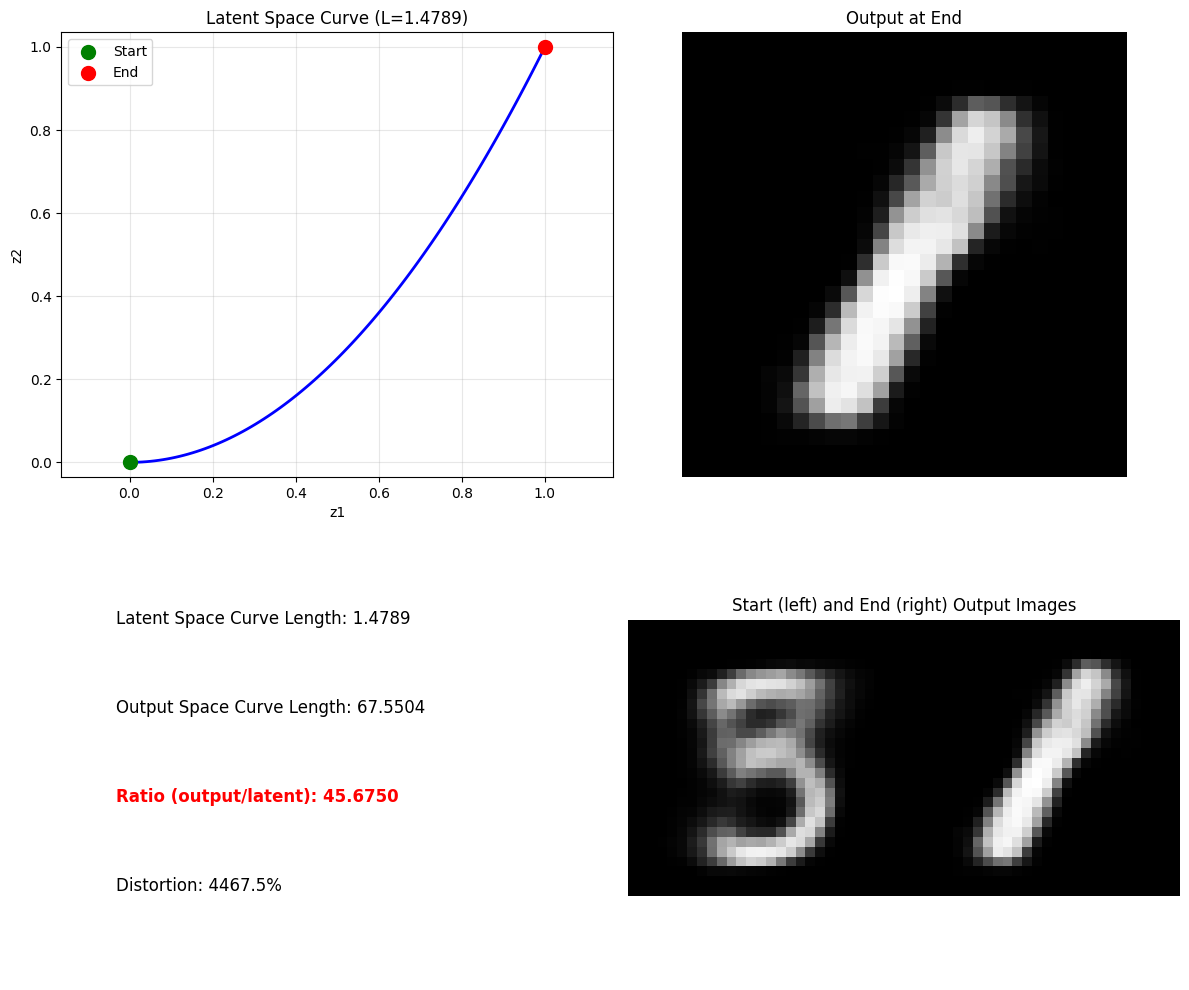

In [72]:
print("\nVisualizing curves...")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot 1: Latent curve
axes[0, 0].plot(latent_points[:, 0], latent_points[:, 1], 'b-', linewidth=2)
axes[0, 0].scatter(latent_points[0, 0], latent_points[0, 1], color='g', s=100, label='Start', zorder=5)
axes[0, 0].scatter(latent_points[-1, 0], latent_points[-1, 1], color='r', s=100, label='End', zorder=5)
axes[0, 0].set_xlabel('z1')
axes[0, 0].set_ylabel('z2')
axes[0, 0].set_title(f'Latent Space Curve (L={latent_length:.4f})')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()
axes[0, 0].axis('equal')

# Plot 2: Sample output images at different points
sample_indices = [0, len(output_points)//2, len(output_points)-1]
sample_titles = ['Start', 'Middle', 'End']
for idx, (sample_idx, title) in enumerate(zip(sample_indices, sample_titles)):
    axes[0, 1].imshow(output_points[sample_idx], cmap='gray')
    axes[0, 1].set_title(f'Output at {title}')
    axes[0, 1].axis('off')

# Plot 3: Statistics
axes[1, 0].text(0.1, 0.8, f'Latent Space Curve Length: {latent_length:.4f}', fontsize=12, transform=axes[1, 0].transAxes)
axes[1, 0].text(0.1, 0.6, f'Output Space Curve Length: {output_length:.4f}', fontsize=12, transform=axes[1, 0].transAxes)
axes[1, 0].text(0.1, 0.4, f'Ratio (output/latent): {output_length/latent_length:.4f}', fontsize=12, transform=axes[1, 0].transAxes, color='red', weight='bold')
axes[1, 0].text(0.1, 0.2, f'Distortion: {(output_length/latent_length - 1)*100:.1f}%', fontsize=12, transform=axes[1, 0].transAxes)
axes[1, 0].axis('off')

# Plot 4: Show first and last output images side-by-side
axes[1, 1].imshow(np.hstack([output_points[0], output_points[-1]]), cmap='gray')
axes[1, 1].set_title('Start (left) and End (right) Output Images')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()


## Notes

You can modify the `latent_curve()` coefficients above and re-run to see how different paths through latent space map to output space.